In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
file_id = "1ZedM7V4ky54251MlnZpYket4z3cjfLrd"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url, sep=",")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,country_grouped
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,01/07/2015,Portugal
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,01/07/2015,Portugal
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,02/07/2015,Northern Europe
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,02/07/2015,Northern Europe
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,03/07/2015,Northern Europe


In [4]:
pd.set_option('display.max_columns', None)

##**Reservation Status in Different Hotels**

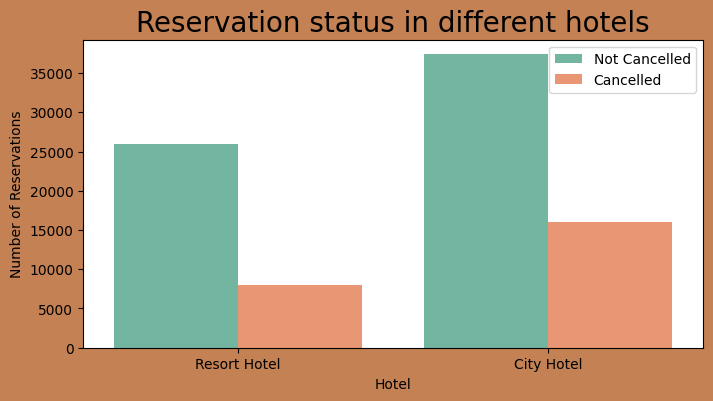

In [5]:
# Set the background color of the figure
plt.figure(figsize=(8, 4), facecolor='#C38154')

# Create the countplot
ax1 = sns.countplot(x='hotel', hue='is_canceled', data=df, palette="Set2")

# Customize legend location
legend_labels, _ = ax1.get_legend_handles_labels()
ax1.legend(bbox_to_anchor=(1, 1))

# Set plot title and axis labels
plt.title('Reservation status in different hotels', size=20, color='Black')
plt.xlabel('Hotel',color='Black')
plt.ylabel('Number of Reservations', color='Black')

# Customize legend labels
plt.legend(['Not Cancelled', 'Cancelled'])

# Show the plot
plt.show()

Berdasarkan visualisasi tersebut, terlihat bahwa City Hotel memiliki jumlah reservasi yang jauh lebih tinggi dibandingkan Resort Hotel, baik untuk reservasi yang berhasil (not cancelled) maupun yang dibatalkan (cancelled). Hal ini menunjukkan bahwa permintaan terhadap City Hotel lebih besar, kemungkinan karena lokasinya yang lebih strategis untuk kebutuhan bisnis, perjalanan singkat, maupun wisata perkotaan.

Pada City Hotel, jumlah pembatalan reservasi juga terlihat cukup tinggi dibandingkan Resort Hotel. Meskipun jumlah reservasi sukses tetap mendominasi, tingginya angka pembatalan ini menunjukkan bahwa City Hotel memiliki risiko cancellation yang lebih besar. Hal ini dapat disebabkan oleh karakteristik tamu City Hotel yang cenderung melakukan booking lebih fleksibel, seperti perjalanan bisnis yang sering berubah jadwal atau pemesanan last-minute yang lebih mudah dibatalkan.

Sementara itu, Resort Hotel memiliki total reservasi yang lebih rendah, tetapi juga menunjukkan jumlah pembatalan yang lebih kecil. Hal ini mengindikasikan bahwa tamu Resort Hotel cenderung memiliki komitmen menginap yang lebih tinggi karena biasanya reservasi dilakukan untuk tujuan liburan, family trip, atau perjalanan yang sudah direncanakan jauh hari.

## **Reservation Status per Month**

In [6]:
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date'],
    dayfirst=True,
    errors='coerce')

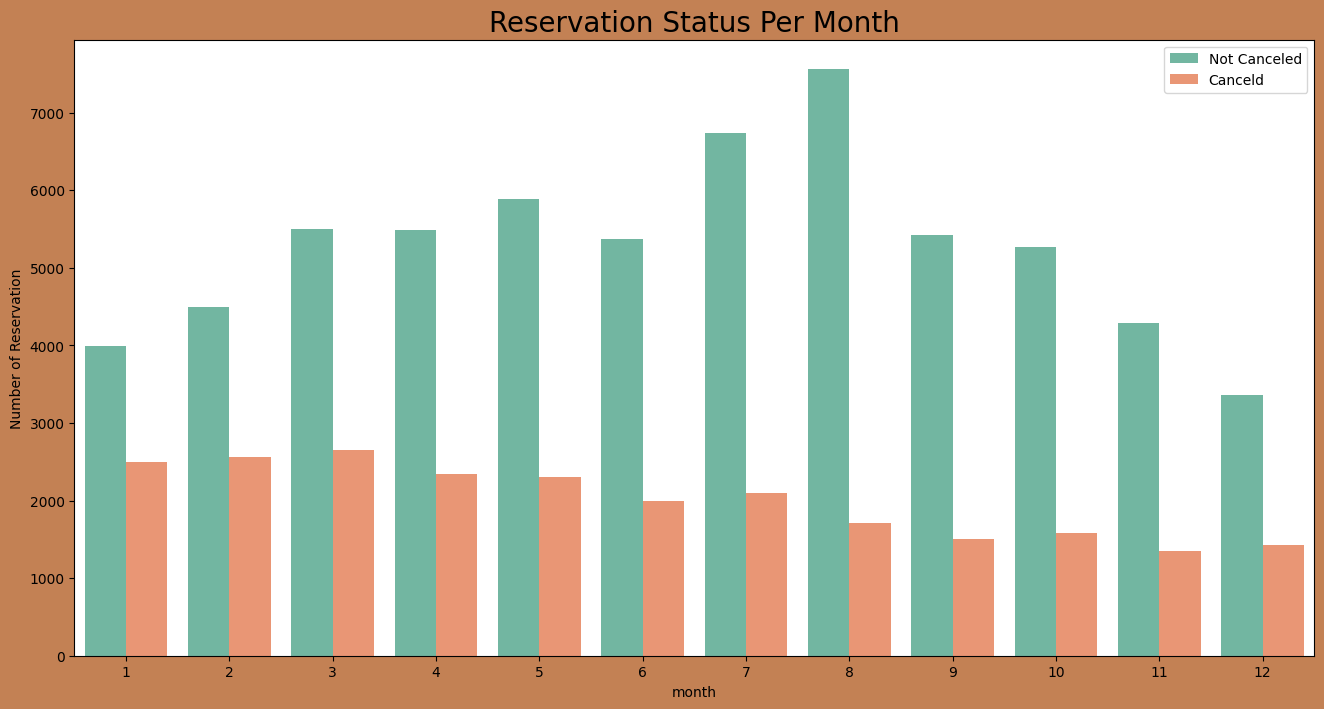

In [7]:
df['month']=df['reservation_status_date'].dt.month
plt.figure(figsize=(16,8), facecolor='#C38154')
ax1 = sns.countplot(x='month', hue='is_canceled', data= df, palette = 'Set2')
legend_lebels,_ = ax1.get_legend_handles_labels()
plt.title('Reservation Status Per Month', size = 20)
plt.xlabel('month')
plt.ylabel('Number of Reservation')
plt.legend(['Not Canceled','Canceld'])
plt.show()

Berdasarkan visualisasi status reservasi per bulan, terlihat bahwa jumlah reservasi yang tidak dibatalkan (Not Canceled) selalu lebih tinggi dibandingkan reservasi yang dibatalkan (Canceled) pada setiap bulan. Hal ini menunjukkan bahwa sebagian besar pelanggan tetap melanjutkan pemesanannya hingga proses menginap, yang merupakan indikator positif bagi tingkat okupansi hotel.

Jumlah reservasi yang berhasil (tidak dibatalkan) paling tinggi terjadi pada bulan Agustus (bulan ke-8), diikuti oleh bulan Juli (bulan ke-7). Hal ini menunjukkan bahwa hotel mengalami permintaan tertinggi pada musim liburan musim panas, di mana lebih banyak tamu yang benar-benar melanjutkan reservasinya tanpa pembatalan. Periode ini kemungkinan merupakan high season yang memberikan kontribusi besar terhadap pendapatan hotel.

Di sisi lain, jumlah reservasi yang dibatalkan terlihat relatif lebih tinggi pada awal hingga pertengahan tahun, khususnya sekitar bulan Maret hingga Mei (bulan ke-3 sampai ke-5). Kondisi ini dapat mengindikasikan bahwa tamu yang melakukan booking pada periode tersebut cenderung lebih sering mengubah rencana perjalanan.

##**Top 10 Countries with Reservation Canceled**

In [8]:
df['country_grouped'].value_counts()

,count
country_grouped,
Portugal,27453
Western Europe,21002
Northern Europe,15851
Southern Europe,10701
South America,2447
Eastern Europe,2324
Eastern Asia,2287
Northern America,1875
Western Asia,912


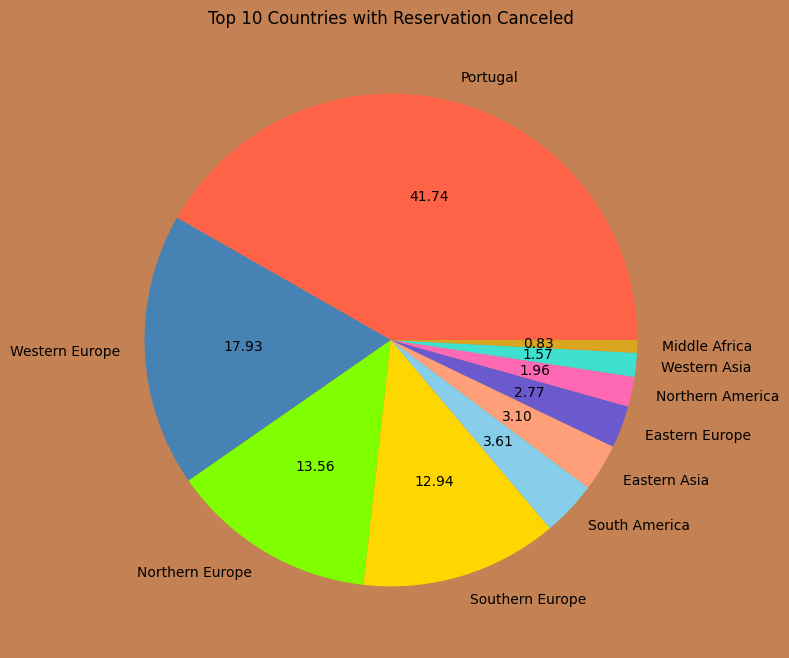

In [9]:
cancelled_data= df[df['is_canceled']==1]
top_10_country = cancelled_data['country_grouped'].value_counts()[:10]
# plt.figure(figsize=(8,8), facecolor='#C38154')
# plt.title('Top 10 countries with reservation canceled',color="black")
# plt.pie(top_10_country, autopct ='%.2f', labels = top_10_country.index)
# plt.show()

# Custom colors for the pie chart
custom_colors = ['#FF6347', '#4682B4', '#7FFF00', '#FFD700', '#87CEEB', '#FFA07A', '#6A5ACD', '#FF69B4', '#40E0D0', '#DAA520']

plt.figure(figsize=(8, 8), facecolor='#C38154')  # Set background color to a light brown
plt.title('Top 10 Countries with Reservation Canceled', color="black")
plt.pie(top_10_country, autopct='%.2f', labels=top_10_country.index, colors=custom_colors)
plt.show()

Berdasarkan visualisasi pie chart, terlihat bahwa Portugal menjadi negara dengan persentase pembatalan reservasi tertinggi, yaitu sebesar 41,74% dari total pembatalan pada 10 negara teratas. Hal ini menunjukkan bahwa sebagian besar pembatalan reservasi berasal dari pelanggan domestik, yang kemungkinan disebabkan oleh tingginya volume pemesanan dari pasar lokal dibandingkan negara lainnya.

Posisi kedua ditempati oleh Western Europe dengan kontribusi pembatalan sebesar 17,93%, diikuti oleh Northern Europe (13,56%) dan Southern Europe (12,94%). Hal ini menunjukkan bahwa pasar utama hotel masih didominasi oleh kawasan Eropa, baik domestik maupun internasional, sehingga perilaku pembatalan dari wilayah ini sangat berpengaruh terhadap tingkat okupansi hotel.

Sementara itu, kontribusi pembatalan dari wilayah lain seperti South America (3,61%), Eastern Asia (3,10%), Eastern Europe (2,77%), hingga Middle Africa (0,83%) relatif lebih kecil. Ini menunjukkan bahwa pelanggan dari luar kawasan utama memiliki proporsi pembatalan yang lebih rendah, meskipun tetap perlu diperhatikan dalam strategi pemasaran internasional.

##**Hotel Price**

In [10]:
# Hapus data dengan total tamu = 0
df = df[(df['adults'] + df['children']) > 0]

# Buat kolom harga per orang per malam
df['adr_pp'] = df['adr'] / (df['adults'] + df['children'])

# Pisahkan berdasarkan tipe hotel
rh = df[df['hotel'] == 'Resort Hotel']
ch = df[df['hotel'] == 'City Hotel']

# Tampilkan hasil
print("""
Resort Hotel: {:.2f} € per night and person
City Hotel: {:.2f} € per night and person
""".format(rh["adr_pp"].mean(), ch["adr_pp"].mean()))


Resort Hotel: 49.91 € per night and person
City Hotel: 59.52 € per night and person



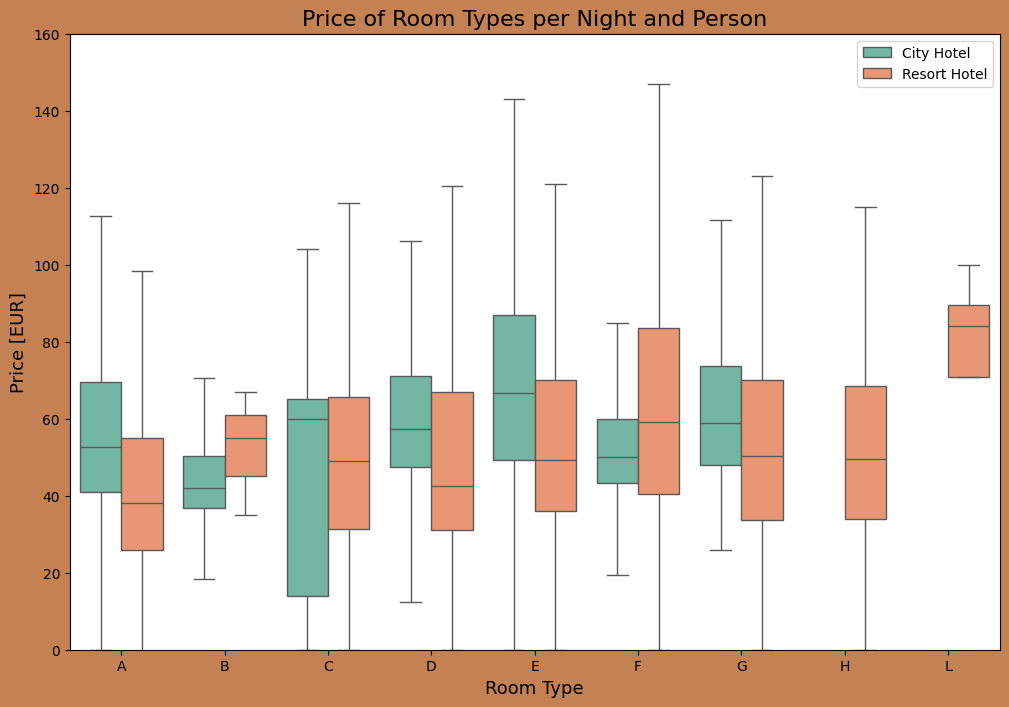

In [11]:
# hanya ambil data tamu yang benar-benar datang (not canceled)
full_data_guests = df[df['is_canceled'] == 0]

# ambil kolom yang dibutuhkan
room_prices = full_data_guests[
    ['hotel', 'reserved_room_type', 'adr_pp']
].sort_values('reserved_room_type')

plt.figure(figsize=(12, 8), facecolor='#C38154')

sns.boxplot(
    x='reserved_room_type',
    y='adr_pp',
    hue='hotel',
    data=room_prices,
    hue_order=['City Hotel', 'Resort Hotel'],
    fliersize=0,
    palette='Set2'
)

plt.title('Price of Room Types per Night and Person', fontsize=16, color='black')
plt.xlabel('Room Type', fontsize=13)
plt.ylabel('Price [EUR]', fontsize=13)
plt.legend(loc='upper right')
plt.ylim(0, 160)

plt.show()

In [17]:
room_prices.sort_values('adr_pp')

,hotel,reserved_room_type,adr_pp
11591,Resort Hotel,A,-3.19
53083,City Hotel,A,0.00
36500,City Hotel,D,0.00
61287,City Hotel,A,0.00
52820,City Hotel,A,0.00
...,...,...,...
83295,City Hotel,F,270.00
80782,City Hotel,A,285.00
80763,City Hotel,A,285.00
80185,City Hotel,G,285.00


Berdasarkan visualisasi boxplot tersebut, terlihat bahwa terdapat perbedaan harga yang cukup signifikan antar tipe kamar pada City Hotel dan Resort Hotel. Secara umum, beberapa tipe kamar premium seperti Room Type E, F, dan L memiliki harga per malam per orang yang lebih tinggi dibandingkan tipe kamar lainnya, yang menunjukkan bahwa tipe kamar tersebut kemungkinan menawarkan fasilitas yang lebih eksklusif, ukuran kamar yang lebih besar, atau lokasi kamar yang lebih strategis.

Pada City Hotel, tipe kamar E menunjukkan median harga yang cukup tinggi dengan rentang harga yang lebar, menandakan bahwa kamar ini merupakan salah satu kategori premium dengan variasi harga yang cukup besar tergantung musim, permintaan, atau karakteristik tamu. Sementara itu, pada Resort Hotel, tipe kamar L memiliki harga tertinggi dibanding tipe lainnya, dengan median yang jauh lebih tinggi, yang mengindikasikan bahwa kamar ini kemungkinan merupakan tipe kamar paling eksklusif di Resort Hotel.

Selain itu, beberapa tipe kamar seperti A dan B memiliki harga yang relatif lebih rendah dan stabil, sehingga dapat dikategorikan sebagai tipe kamar standar yang paling umum dipesan oleh tamu. Rentang harga yang lebih sempit pada tipe ini menunjukkan harga yang lebih konsisten dan lebih terjangkau.

/tmp/ipykernel_6640/174599284.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.lineplot(


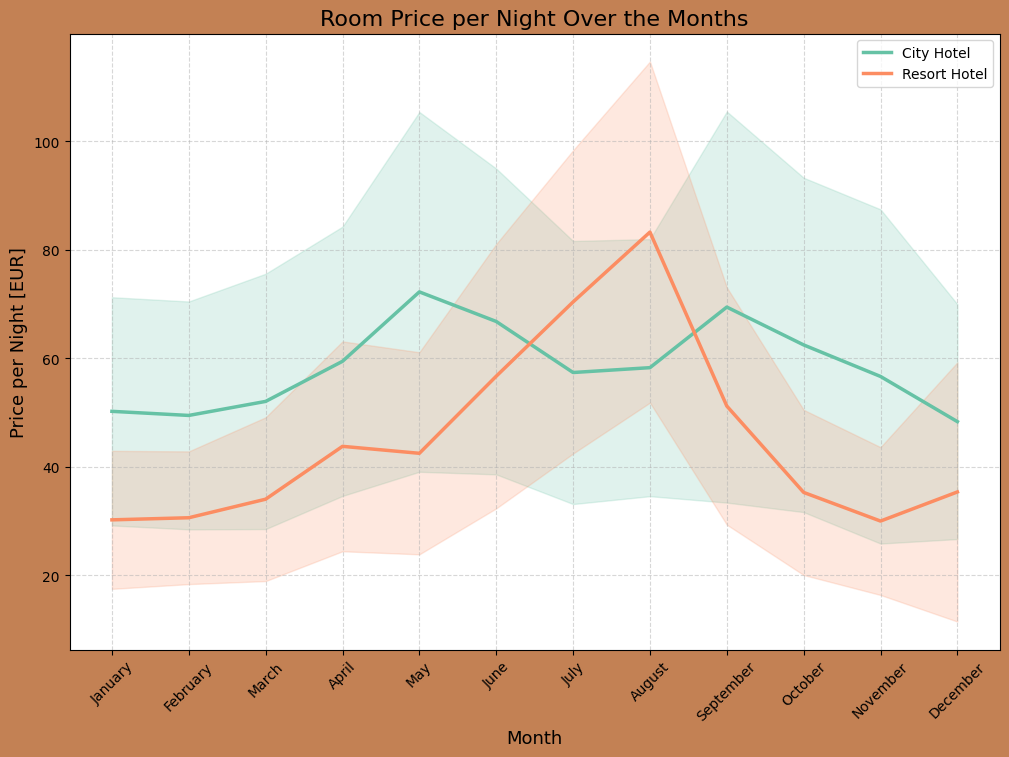

In [13]:
# hanya ambil tamu yang benar-benar datang (not canceled)
full_data_guests = df[df['is_canceled'] == 0]

# ambil data harga kamar per bulan
room_prices_monthly = full_data_guests[
    ['hotel', 'arrival_date_month', 'adr_pp']
].copy()

# urutan bulan yang benar
ordered_months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

room_prices_monthly['arrival_date_month'] = pd.Categorical(
    room_prices_monthly['arrival_date_month'],
    categories=ordered_months,
    ordered=True
)

room_prices_monthly = room_prices_monthly.sort_values('arrival_date_month')

# visualisasi line graph
plt.figure(figsize=(12, 8), facecolor='#C38154')

ax = sns.lineplot(
    x='arrival_date_month',
    y='adr_pp',
    hue='hotel',
    data=room_prices_monthly,
    hue_order=['City Hotel', 'Resort Hotel'],
    palette='Set2',
    ci='sd',
    linewidth=2.5
)

# grid background
ax.grid(True, linestyle='--', alpha=0.5)

plt.title('Room Price per Night Over the Months', fontsize=16, color='black')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Price per Night [EUR]', fontsize=13)
plt.xticks(rotation=45)

plt.legend(loc='upper right')
plt.show()

Berdasarkan visualisasi line graph tersebut, terlihat bahwa harga kamar per malam pada City Hotel dan Resort Hotel mengalami fluktuasi sepanjang tahun, yang menunjukkan adanya pengaruh musim, permintaan pelanggan, serta periode liburan terhadap strategi penetapan harga hotel.

Pada City Hotel, harga kamar cenderung lebih stabil sepanjang tahun dengan kenaikan yang cukup jelas pada periode Mei hingga September, terutama pada bulan Mei dan September. Hal ini menunjukkan bahwa permintaan terhadap City Hotel meningkat pada periode tersebut, kemungkinan dipengaruhi oleh musim liburan, business travel, maupun peak season wisata perkotaan.

Sementara itu, pada Resort Hotel, pola harga terlihat lebih fluktuatif dan mencapai puncaknya pada bulan Agustus, dengan harga tertinggi dibanding bulan lainnya. Kondisi ini sangat wajar karena bulan Agustus biasanya merupakan periode liburan musim panas di Eropa, sehingga permintaan terhadap Resort Hotel meningkat tajam, terutama untuk wisata keluarga dan liburan internasional.

Selain itu, harga Resort Hotel pada awal dan akhir tahun cenderung lebih rendah, seperti pada bulan Januari, Februari, November, dan Desember, yang menunjukkan adanya low season dengan tingkat permintaan yang lebih rendah. Sebaliknya, City Hotel tetap mempertahankan harga yang relatif stabil karena permintaannya tidak hanya bergantung pada musim liburan, tetapi juga pada perjalanan bisnis dan kebutuhan akomodasi harian.

##**Reservation per Month**

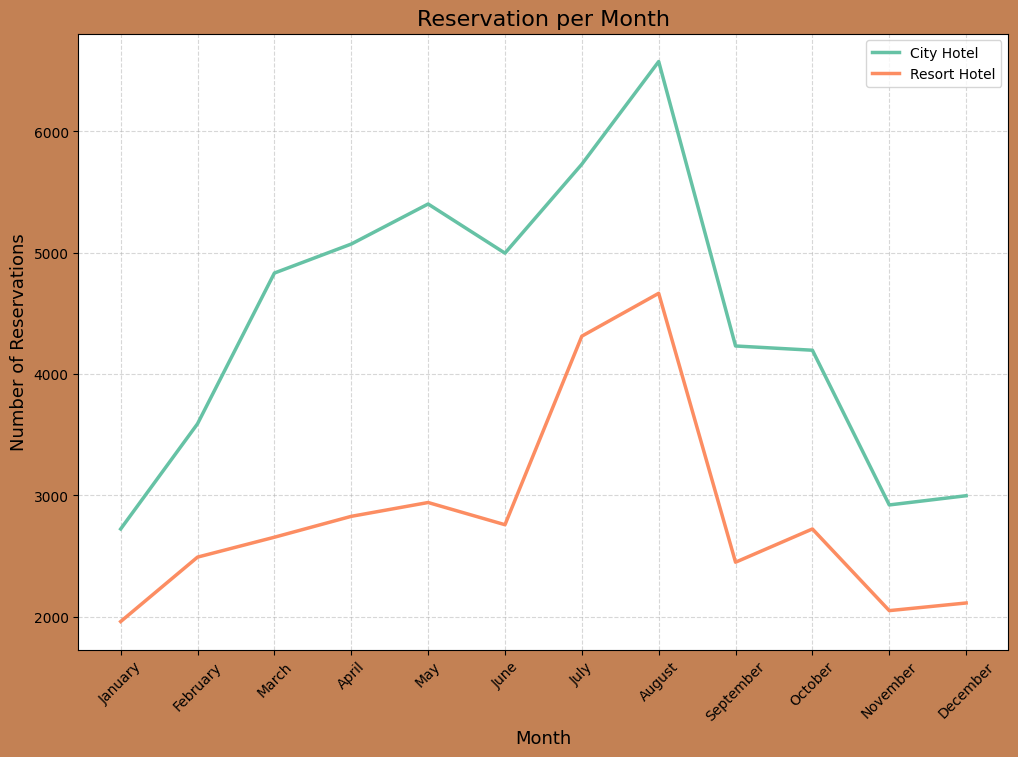

In [14]:
# menghitung jumlah reservasi berdasarkan bulan dan tipe hotel
monthly_booking = df.groupby(
    ['arrival_date_month', 'hotel']
).size().reset_index(name='total_booking')

# urutan bulan yang benar
ordered_months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_booking['arrival_date_month'] = pd.Categorical(
    monthly_booking['arrival_date_month'],
    categories=ordered_months,
    ordered=True
)

monthly_booking = monthly_booking.sort_values('arrival_date_month')

# style dengan kotak/grid di belakang
plt.figure(figsize=(12, 8), facecolor='#C38154')

ax = sns.lineplot(
    x='arrival_date_month',
    y='total_booking',
    hue='hotel',
    data=monthly_booking,
    hue_order=['City Hotel', 'Resort Hotel'],
    palette='Set2',
    linewidth=2.5
)

# menambahkan grid (kotak-kotak background)
ax.grid(True, linestyle='--', alpha=0.5)

plt.title('Reservation per Month', fontsize=16, color='black')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Number of Reservations', fontsize=13)
plt.xticks(rotation=45)

plt.legend(loc='upper right')
plt.show()

Berdasarkan visualisasi line graph tersebut, terlihat bahwa jumlah reservasi pada City Hotel dan Resort Hotel mengalami pola fluktuasi yang cukup jelas sepanjang tahun, yang mengindikasikan adanya pengaruh kuat dari faktor musiman (seasonality), periode liburan, serta pola perjalanan wisatawan.

Pada City Hotel, jumlah reservasi menunjukkan tren peningkatan yang stabil dari awal tahun hingga mencapai puncaknya pada periode Juli hingga Agustus, dengan titik tertinggi di bulan Agustus. Setelah itu, terjadi penurunan yang cukup signifikan mulai bulan September hingga November, sebelum kembali sedikit meningkat di bulan Desember. Pola ini menunjukkan bahwa meskipun City Hotel memiliki demand yang relatif stabil (kemungkinan dari business travel), tetap terdapat peningkatan signifikan saat peak season liburan.

Sementara itu, pada Resort Hotel, pola reservasi terlihat lebih fluktuatif dan sangat dipengaruhi oleh musim liburan. Jumlah reservasi meningkat secara tajam mulai bulan Juni, mencapai puncaknya pada bulan Agustus, lalu mengalami penurunan drastis setelahnya. Hal ini menunjukkan bahwa Resort Hotel sangat bergantung pada periode liburan, terutama musim panas, di mana wisatawan cenderung memilih destinasi resort untuk berlibur.

Selain itu, pada awal dan akhir tahun seperti Januari, Februari, dan November, kedua hotel sama-sama mengalami jumlah reservasi yang lebih rendah, yang mengindikasikan periode low season dengan tingkat permintaan yang menurun. Namun, City Hotel tetap menunjukkan performa yang lebih stabil dibanding Resort Hotel sepanjang tahun.

##**Rekomendasi**



1. Menerapkan sistem deposit bertingkat berdasarkan risiko pembatalan
Karena tingkat pembatalan cukup tinggi terutama pada City Hotel serta pada periode tertentu seperti Maret–Mei, diperlukan mekanisme yang dapat meningkatkan komitmen pelanggan terhadap reservasi. Booking dengan lead time yang panjang cenderung memiliki kemungkinan cancel lebih besar karena pelanggan memiliki lebih banyak waktu untuk mengubah rencana perjalanan. Dengan adanya deposit bertingkat, pelanggan akan lebih mempertimbangkan keputusan pembatalan karena sudah memiliki komitmen finansial.   
Contohnya:   
    - Lead time > 60 hari → deposit 30%
    - Lead time > 90 hari → deposit 50%
    - Customer dengan riwayat previous cancellation tinggi → mandatory deposit
    - High season booking → partial payment wajib
2. Strategi bundling untuk kamar premium yang kurang optimal terjual
Visualisasi boxplot menunjukkan bahwa Room Type E, F, dan L memiliki harga tertinggi sehingga berpotensi memberikan profit lebih besar. Namun, harga yang tinggi juga dapat menjadi hambatan pembelian, terutama saat demand tidak terlalu tinggi.
Karena itu, bundling diperlukan agar pelanggan merasa value yang diterima lebih besar dibanding hanya membeli kamar saja. Paket ini dapat diberikan diskon 10–15% dibanding pembelian terpisah agar meningkatkan conversion rate kamar premium. Strategi ini dapat meningkatkan conversion rate untuk kamar premium sekaligus menaikkan average revenue per booking.   
Contohnya:   
    - Room Type E + breakfast + airport transfer
    - Room Type F + spa voucher + late checkout
    - Room Type L + family dinner package
3. Promo low season untuk menjaga okupansi kamar standar
Pada bulan Januari, Februari, November, dan Desember terlihat jumlah reservasi lebih rendah dibanding peak season. Jika tidak diantisipasi, low season dapat menurunkan occupancy rate dan pendapatan hotel.
Karena itu, hotel perlu fokus pada kamar standar seperti Room Type A dan B yang lebih terjangkau dan lebih mudah dijual saat demand rendah. Tujuannya adalah menjaga cashflow tetap stabil meskipun berada di periode low season.
Contohnya:   
    - Stay 3 Nights Pay 2
    - Weekday Business Package
    - Long Stay Discount
    - Domestic Traveler Special Promo
4. Program retensi khusus untuk pelanggan Portugal
Pie chart menunjukkan bahwa Portugal menyumbang pembatalan reservasi terbesar yaitu 41,74%. Hal ini menandakan bahwa pasar domestik memiliki pengaruh paling besar terhadap tingkat cancellation hotel.
Daripada terus mencari customer baru, akan lebih efisien jika hotel meningkatkan retensi pelanggan domestik yang sudah familiar dengan brand hotel. Strategi ini bertujuan mengubah pelanggan domestik dari frequent canciller menjadi loyal customer.   
Contohnya:   
    - Repeat guest discount
    - Loyalty membership khusus domestic traveler
    - Cashback voucher untuk next booking
    - Priority booking privilege
5. Dynamic pricing berdasarkan peak season dan tipe hotel
Dari line chart terlihat bahwa bulan Juli–Agustus merupakan peak season dengan reservasi dan harga kamar tertinggi, terutama pada Resort Hotel. Ini menunjukkan adanya willingness to pay yang lebih tinggi dari pelanggan pada periode tersebut.
Karena itu, hotel perlu menerapkan dynamic pricing agar revenue dapat dimaksimalkan saat demand tinggi dan tetap kompetitif saat demand rendah. Strategi ini membantu optimalisasi profit tanpa harus menambah jumlah kamar.   
Contohnya:   
    - Premium room surcharge saat high season
    - Weekend rate increase
    - Last-minute premium pricing
    - Early bird promo saat low season  

In [15]:
df.to_excel('hotel_booking_clean.xlsx', index=False)